## **IMPORT NECESSARY LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

Loading in the data.

In [ ]:
df = pd.read_excel("../merged_data/merged_output_cleaned.xlsx")

df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          4200 non-null   int64  
 1   immigrant     4200 non-null   object 
 2   type of work  4200 non-null   object 
 3   education     4200 non-null   object 
 4   both sexes    4200 non-null   float64
 5   men           4200 non-null   float64
 6   women         4200 non-null   float64
 7   gender        4200 non-null   object 
 8   earnings      4200 non-null   float64
 9   wages_salary  4200 non-null   float64
 10  total_income  4200 non-null   float64
dtypes: float64(6), int64(1), object(4)
memory usage: 361.1+ KB


## **1. UNIVARIATE ANALYSIS**

**1.1. Summary Statistics for the Numeric Columns.**

In [3]:
df[["both sexes", "men", "women", "earnings", "wages_salary", "total_income"]].describe()

,both sexes,men,women,earnings,wages_salary,total_income
count,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000
mean,16.562333,14.650429,13.588619,30690.894398,29009.988827,49707.386489
std,10.634964,13.169453,10.999202,20003.351272,19073.888163,20167.370650
min,0.000000,0.000000,0.000000,3922.711670,3614.759725,19521.143474
25%,14.000000,0.000000,0.000000,14249.748744,13810.093897,35198.032070
50%,18.000000,17.000000,16.500000,27005.960854,26153.461880,43751.111407
75%,23.000000,24.000000,21.000000,41568.495763,39301.271186,59582.118644
max,42.700000,45.700000,40.900000,84021.577446,79098.683633,111537.297060


This table summarizes the central tendncy and spread of key numeric variables.

**1.2. Categorical Distrbution.**

In [4]:
df["education"].value_counts()
df["immigrant"].value_counts()
df["gender"].value_counts()
df["type of work"].value_counts()
df["year"].value_counts().sort_index()

,count
year,
2018,840
2019,840
2020,840
2021,840
2022,840


The counts shows how workers are distributed across the various education levels, immigrant status, gender, type of work and years. This gives an overview of the data we are working with.

**1.3. Wage Distribution.**

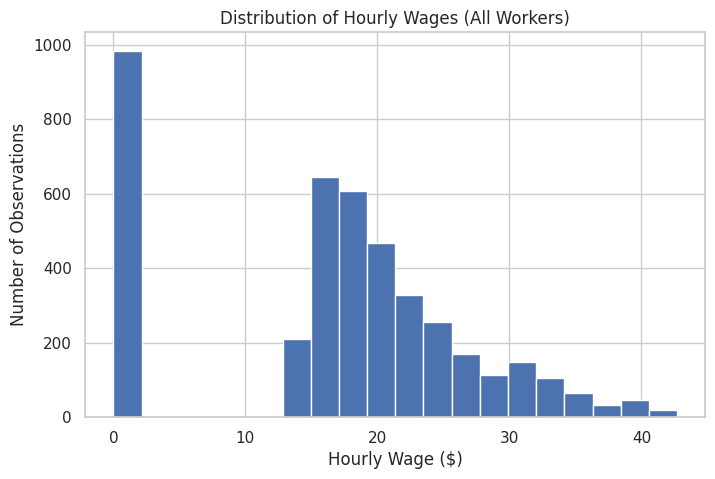

In [5]:
plt.figure(figsize=(8,5))
df["both sexes"].hist(bins=20)
plt.title("Distribution of Hourly Wages (All Workers)")
plt.xlabel("Hourly Wage ($)")
plt.ylabel("Number of Observations")
plt.show()

This chart shows the distribution of hourly wages for all workers and also helps us see if the distibution is skewed.

**1.4. Total Annual Income**

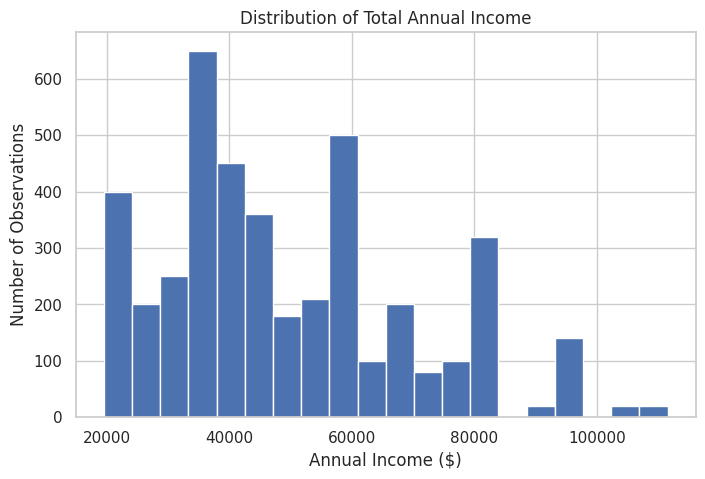

In [6]:
plt.figure(figsize=(8,5))
df["total_income"].hist(bins=20)
plt.title("Distribution of Total Annual Income")
plt.xlabel("Annual Income ($)")
plt.ylabel("Number of Observations")
plt.show()

This chart helps to identify income inequality, skewness and possible outliers.

## **2. BIVARIATE ANALYSIS**

**2.1. Average hourly Wage by Education level.**

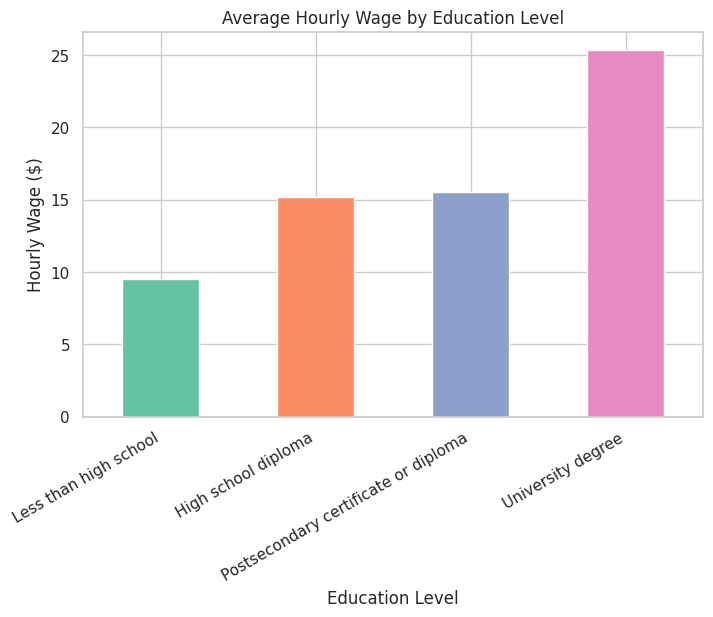

In [7]:
edu_means = df.groupby("education")["both sexes"].mean().sort_values()

color_map = {
    "Less than high school": "#66c2a5",
    "High school diploma": "#fc8d62",
    "Postsecondary certificate or diploma": "#8da0cb",
    "University degree": "#e78ac3"
}
edu_order = edu_means.index
colors = [color_map.get(e, "#999999") for e in edu_order]

plt.figure(figsize=(8,5))
edu_means.plot(kind="bar", color=colors)
plt.title("Average Hourly Wage by Education Level")
plt.ylabel("Hourly Wage ($)")
plt.xlabel("Education Level")
plt.xticks(rotation=30, ha="right")
plt.show()

This chart shows the average hourly wage for each education level. It shows how wages increases as education moves from less than high school to university degree.

**2.2. Average Hourly Wage by Immigrant Status.**

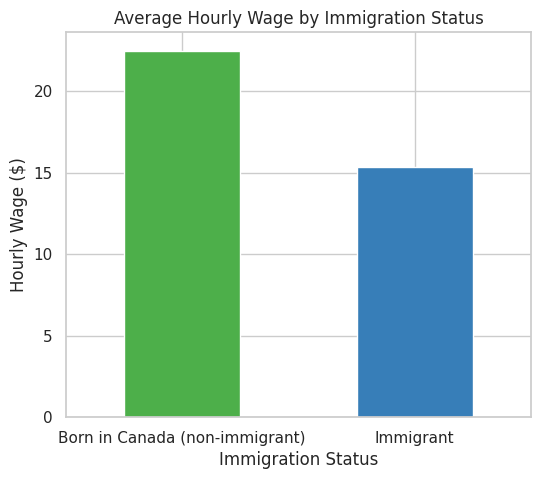

In [8]:
imm_means = df.groupby("immigrant")["both sexes"].mean()

plt.figure(figsize=(6,5))
imm_means.plot(kind="bar", color=["#4daf4a", "#377eb8"])
plt.title("Average Hourly Wage by Immigration Status")
plt.ylabel("Hourly Wage ($)")
plt.xlabel("Immigration Status")
plt.xticks(rotation=0)
plt.show()

This chart compares the average hourly wage between immigrants and Canadian born. It shows the wage gap that is associated with the immigration status.

**2.3. Gender Wage Comparsion (Men Vs. Women).**

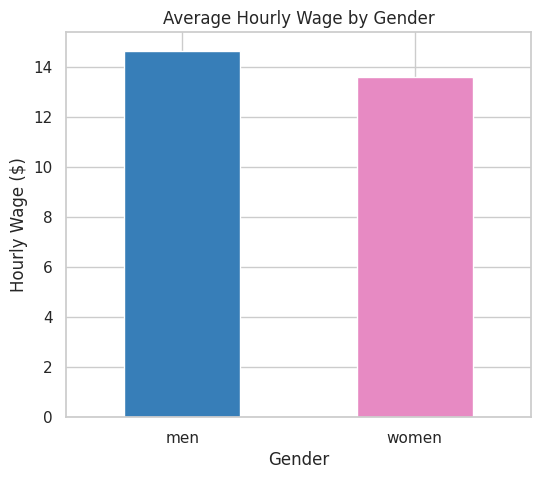

In [9]:
plt.figure(figsize=(6,5))
df[["men", "women"]].mean().plot(kind="bar", color=["#377eb8", "#e78ac3"])
plt.title("Average Hourly Wage by Gender")
plt.ylabel("Hourly Wage ($)")
plt.xlabel("Gender")
plt.xticks(rotation=0)
plt.show()

This chart shows the average hourly wage for men and women using the Edata wage column. Gives a simple view of what the wage data looks like based on the gender.

**2.4. Average hourly wage by type of work (Full-time vs Part-time).**

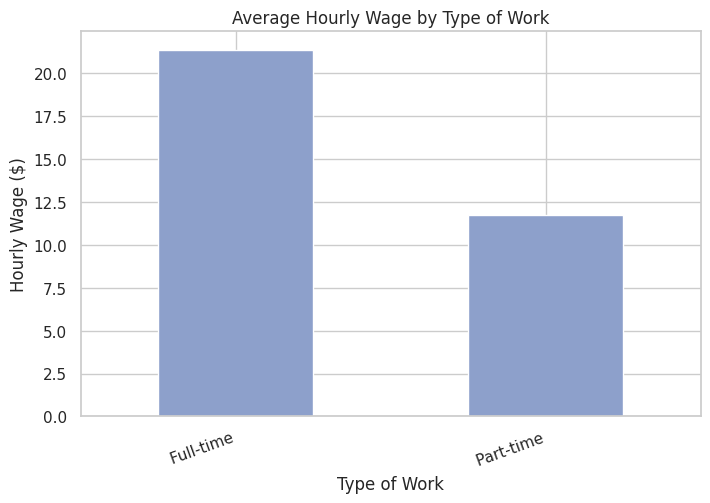

In [10]:
plt.figure(figsize=(8,5))
df.groupby("type of work")["both sexes"].mean().plot(kind="bar", color="#8da0cb")
plt.title("Average Hourly Wage by Type of Work")
plt.ylabel("Hourly Wage ($)")
plt.xlabel("Type of Work")
plt.xticks(rotation=20, ha="right")
plt.show()

This chart shows the differences between full time and part time works.

**2.5. Education and Immigrant Status.**

/tmp/ipython-input-3941690670.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


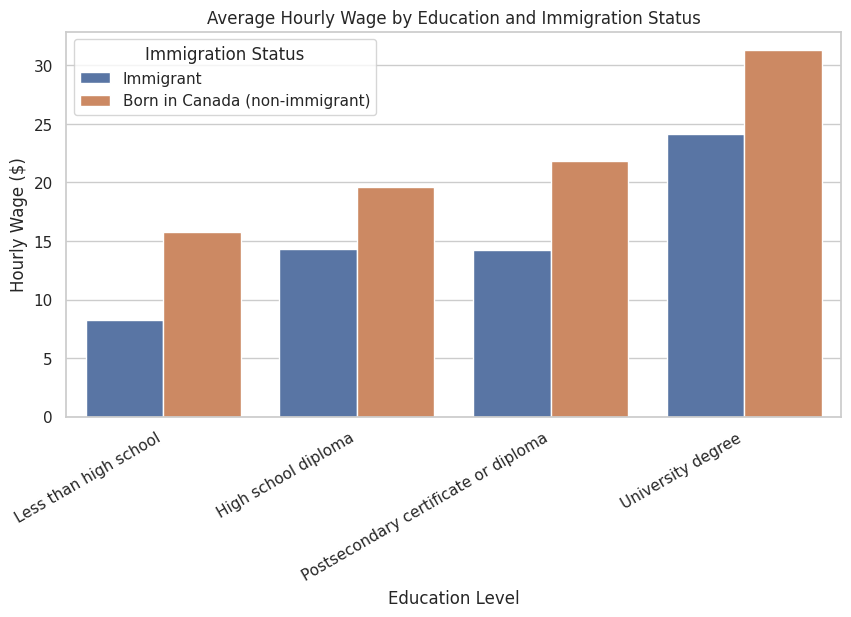

In [11]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=df,
    x="education",
    y="both sexes",
    hue="immigrant",
    estimator="mean",
    ci=None
)
plt.title("Average Hourly Wage by Education and Immigration Status")
plt.ylabel("Hourly Wage ($)")
plt.xlabel("Education Level")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Immigration Status")
plt.show()

This chart shows the average hourly wage by education level, which is then seperated by immigrant status. It shows whether immigrants earns less even at the same education level.

## **3. MULTIVARIATE**

**3.1. Wage Trend Over Time by Immigration Status.**

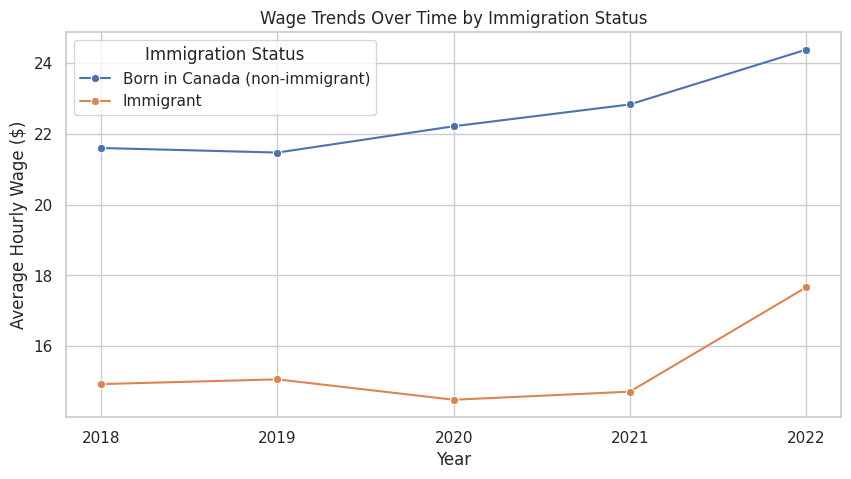

In [12]:
trend_df = (
    df.groupby(["year", "immigrant"], as_index=False)["both sexes"]
      .mean()
)

plt.figure(figsize=(10,5))
sns.lineplot(
    data=trend_df,
    x="year",
    y="both sexes",
    hue="immigrant",
    marker="o"
)
plt.title("Wage Trends Over Time by Immigration Status")
plt.ylabel("Average Hourly Wage ($)")
plt.xlabel("Year")
plt.xticks(sorted(df["year"].unique()))
plt.legend(title="Immigration Status")
plt.show()

/tmp/ipython-input-3280486417.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


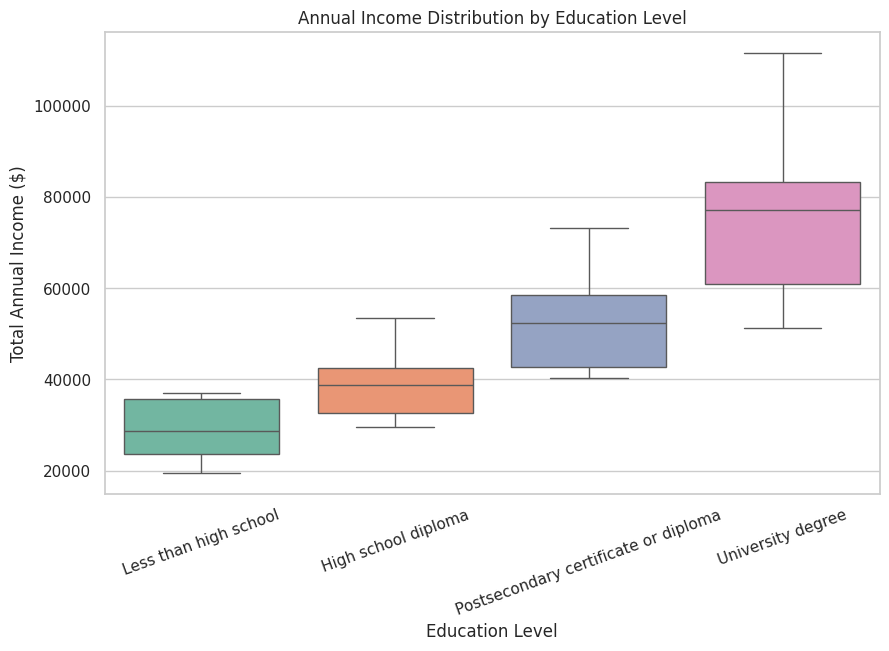

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="education",
    y="total_income",
    palette="Set2"
)
plt.title("Annual Income Distribution by Education Level")
plt.ylabel("Total Annual Income ($)")
plt.xlabel("Education Level")
plt.xticks(rotation=20)
plt.show()


This line chart shows how average hourly wages changes over time for Immigrants and non- immigrants.

**3.2. Education and Immigrant (Average hourly Wage).**

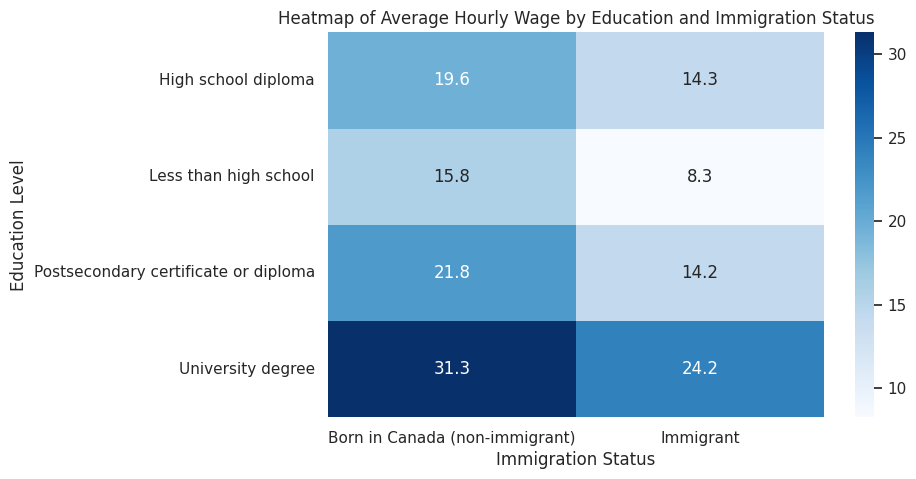

In [14]:
pivot = df.pivot_table(
    values="both sexes",
    index="education",
    columns="immigrant",
    aggfunc="mean"
)

plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Blues")
plt.title("Heatmap of Average Hourly Wage by Education and Immigration Status")
plt.xlabel("Immigration Status")
plt.ylabel("Education Level")
plt.show()

This heatmap shows the average hourly wags for each combination of education level and immigration status. The darker cells shows higher wages(more concentration).